# Полное решение задачи по Au-наночастицам для ОДТ

## Постановка

Нужно оценить концентрацию сферических наночастиц золота диаметром `100 нм`, которая обеспечивает `3-кратную разницу сигнала` на проекции ОДТ в плоско-параллельной конфигурации для ткани мозга мыши при `n = 1.33` и `λ = 800 нм`.

В условии есть две неоднозначности:

1. не задана толщина образца `L`;
2. аббревиатура `ОДТ` может означать:
   - **optical diffraction tomography**: оптическая дифракционная томография;
   - **diffuse optical tomography**: оптическая диффузионная томография.

Поэтому ниже решение доводится до полного вида сразу в двух моделях:

- **Модель A**: проекционное ослабление по закону Бугера-Ламберта-Бера через сечение экстинкции `C_ext` одной Au-сферы.
- **Модель B**: диффузионная томография, где сигнал в плоско-параллельном слое определяется эффективным коэффициентом ослабления `μ_eff = sqrt(3 μ_a (μ_a + μ_s'))`.

Главная идея: если под 3-кратной разницей сигнала понимать отношение `S0 / S = 3`, то соответствующая разность в децибелах всегда равна

`Delta_S_dB = 10 * log10(3) ~= 4.77 dB`

## Источники и принятые данные

- Оптические константы золота `n + i k` взяты из Johnson & Christy (1972) через `refractiveindex.info`:
  <https://refractiveindex.info/?book=Au&page=Johnson&shelf=main>
- Для диффузионной трактовки используются два литературных набора свойств ткани мозга на `800 нм`:
  - обзорные значения для серого вещества `μ_a = 0.036 мм⁻¹`, `μ_s = 22 мм⁻¹`, `g = 0.9` из статьи:
    <https://pmc.ncbi.nlm.nih.gov/articles/PMC11428375/>
  - часто используемая оценка `μ_a ≈ 0.02 мм⁻¹`, `μ_s' ≈ 1.12 мм⁻¹`, обсуждаемая в статье:
    <https://www.mdpi.com/2021324>
- Теоретический фон для диффузионного приближения и slab-геометрии:
  <https://pmc.ncbi.nlm.nih.gov/articles/PMC4482362/>

Поскольку толщина `L` в условии не задана, результат будет приведён:

- как аналитическая функция `N(L)`;
- как таблица для `L = 100 мкм`, `1 мм`, `10 мм`.

Это делает решение полным и пригодным для разных интерпретаций условия.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, spherical_yn

plt.style.use('seaborn-v0_8-whitegrid')

wavelength_um = 0.800
medium_index = 1.33
diameter_nm = 100.0
radius_um = diameter_nm / 2 / 1000

# Johnson & Christy data around 800 nm from refractiveindex.info
jc_wavelength_um = np.array([0.7560, 0.8211])
jc_n = np.array([0.14, 0.16])
jc_k = np.array([4.542, 5.083])

au_n = np.interp(wavelength_um, jc_wavelength_um, jc_n)
au_k = np.interp(wavelength_um, jc_wavelength_um, jc_k)
particle_index = complex(au_n, au_k)
relative_index = particle_index / medium_index

print(f'Au at 800 nm: n = {au_n:.6f}, k = {au_k:.6f}')
print(f'Medium refractive index: n_m = {medium_index:.2f}')
print(f'Relative index m = {relative_index:.6f}')

Au at 800 nm: n = 0.153518, k = 4.907653
Medium refractive index: n_m = 1.33
Relative index m = 0.115427+3.689965j


## Теория Ми для сферы Au, 100 нм

Сначала вычисляем `Q_ext`, `Q_sca`, `Q_abs`, а затем сечения:

`C_i = Q_i * pi * a^2`, where `i in {ext, sca, abs}`.

Для диффузионной модели дополнительно нужен фактор анизотропии рассеяния `g`.

In [2]:
def mie_full(relative_index: complex, size_parameter: float):
    n_max = int(round(size_parameter + 4 * size_parameter ** (1 / 3) + 2)) + 10
    n = np.arange(1, n_max + 1)
    mx = relative_index * size_parameter

    j_x = spherical_jn(n, size_parameter)
    j_x_p = spherical_jn(n, size_parameter, derivative=True)
    y_x = spherical_yn(n, size_parameter)
    y_x_p = spherical_yn(n, size_parameter, derivative=True)
    j_mx = spherical_jn(n, mx)
    j_mx_p = spherical_jn(n, mx, derivative=True)

    psi_x = size_parameter * j_x
    psi_x_p = j_x + size_parameter * j_x_p
    psi_mx = mx * j_mx
    psi_mx_p = j_mx + mx * j_mx_p
    xi_x = size_parameter * (j_x + 1j * y_x)
    xi_x_p = (j_x + 1j * y_x) + size_parameter * (j_x_p + 1j * y_x_p)

    a_n = (
        relative_index * psi_mx * psi_x_p - psi_x * psi_mx_p
    ) / (
        relative_index * psi_mx * xi_x_p - xi_x * psi_mx_p
    )
    b_n = (
        psi_mx * psi_x_p - relative_index * psi_x * psi_mx_p
    ) / (
        psi_mx * xi_x_p - relative_index * xi_x * psi_mx_p
    )

    coeff = 2 * n + 1
    q_ext = (2 / size_parameter ** 2) * np.sum(coeff * np.real(a_n + b_n))
    q_sca = (2 / size_parameter ** 2) * np.sum(coeff * (np.abs(a_n) ** 2 + np.abs(b_n) ** 2))
    q_abs = q_ext - q_sca

    sum1 = 0.0
    for idx in range(1, len(n)):
        ni = n[idx - 1]
        sum1 += (
            ni * (ni + 2) / (ni + 1)
        ) * np.real(a_n[idx - 1] * np.conj(a_n[idx]) + b_n[idx - 1] * np.conj(b_n[idx]))
    sum2 = np.sum(((2 * n + 1) / (n * (n + 1))) * np.real(a_n * np.conj(b_n)))
    g = (4 / (size_parameter ** 2 * q_sca)) * (sum1 + sum2)

    return {
        'n': n,
        'a_n': a_n,
        'b_n': b_n,
        'Qext': float(q_ext),
        'Qsca': float(q_sca),
        'Qabs': float(q_abs),
        'g': float(g),
    }


size_parameter = 2 * math.pi * medium_index * radius_um / wavelength_um
mie = mie_full(relative_index, size_parameter)

geom_area_um2 = math.pi * radius_um ** 2
c_ext_um2 = mie['Qext'] * geom_area_um2
c_sca_um2 = mie['Qsca'] * geom_area_um2
c_abs_um2 = mie['Qabs'] * geom_area_um2

c_ext_cm2 = c_ext_um2 * 1e-8
c_sca_cm2 = c_sca_um2 * 1e-8
c_abs_cm2 = c_abs_um2 * 1e-8

print(f"Size parameter x = {size_parameter:.6f}")
print(f"Qext = {mie['Qext']:.6f}")
print(f"Qsca = {mie['Qsca']:.6f}")
print(f"Qabs = {mie['Qabs']:.6f}")
print(f"g    = {mie['g']:.6f}")
print()
print(f"Cext = {c_ext_um2:.6e} um^2 = {c_ext_cm2:.6e} cm^2")
print(f"Csca = {c_sca_um2:.6e} um^2 = {c_sca_cm2:.6e} cm^2")
print(f"Cabs = {c_abs_um2:.6e} um^2 = {c_abs_cm2:.6e} cm^2")

Size parameter x = 0.522290
Qext = 0.541421
Qsca = 0.468476
Qabs = 0.072945
g    = -0.047003

Cext = 4.252310e-03 um^2 = 4.252310e-11 cm^2
Csca = 3.679405e-03 um^2 = 3.679405e-11 cm^2
Cabs = 5.729050e-04 um^2 = 5.729050e-12 cm^2


## Модель A: ОДТ как проекционная оптическая томография / дифракционная томография в амплитудном канале

Если сигнал интерпретировать как прошедшую мощность в плоско-параллельной конфигурации, то достаточно закона Бугера-Ламберта-Бера:

`I = I0 * exp(-N * C_ext * L)`

и условие `I_0 / I = 3` даёт:

`N_A(L) = ln(3) / (C_ext * L)`

Это наиболее прямое чтение условия, потому что в задаче даны:

- показатель преломления среды;
- длина волны;
- ссылка на `refractiveindex.info`;
- указание использовать Mie-расчёт.

То есть все признаки указывают именно на расчёт через `C_ext`.

In [3]:
def concentration_projection(c_ext_cm2: float, thickness_cm: float) -> float:
    return math.log(3) / (c_ext_cm2 * thickness_cm)


thicknesses_mm = np.array([0.1, 1.0, 10.0])
thicknesses_cm = thicknesses_mm / 10
N_projection = np.array([concentration_projection(c_ext_cm2, L_cm) for L_cm in thicknesses_cm])

for L_mm, N in zip(thicknesses_mm, N_projection):
    print(f'L = {L_mm:>4.1f} mm -> N_A = {N:.6e} particles/cm^3 = {N:.6e} particles/mL')

print()
print(f'Analytical form: N_A(L) = ln(3) / ({c_ext_cm2:.6e} * L_cm)')
print(f'dB difference = {10 * math.log10(3):.6f} dB')

L =  0.1 mm -> N_A = 2.583566e+12 particles/cm^3 = 2.583566e+12 particles/mL
L =  1.0 mm -> N_A = 2.583566e+11 particles/cm^3 = 2.583566e+11 particles/mL
L = 10.0 mm -> N_A = 2.583566e+10 particles/cm^3 = 2.583566e+10 particles/mL

Analytical form: N_A(L) = ln(3) / (4.252310e-11 * L_cm)
dB difference = 4.771213 dB


## Модель B: ОДТ как оптическая диффузионная томография

Если под ОДТ подразумевается **diffuse optical tomography**, то для однородного сильно рассеивающего слоя естественно использовать диффузионное приближение.

В slab-геометрии ослабление можно описать через эффективный коэффициент:

`mu_eff = sqrt(3 * mu_a * (mu_a + mu_s_prime))`

Тогда

`I ~ exp(-mu_eff * L)`

Наночастицы добавляют к ткани вклад:

`Delta_mu_a = N * C_abs`
`Delta_mu_s_prime = N * C_sca * (1 - g)`

Условие трёхкратного изменения сигнала имеет вид:

`I0 / I = exp((mu_eff_new - mu_eff_0) * L) = 3`

Здесь уже требуется фоновая оптика ткани, поэтому ниже считаются два литературных сценария для мозга мыши на `800 нм`.

In [4]:
def concentration_to_delta_mu_mm_inv(N_cm3: float, cross_section_cm2: float) -> float:
    return N_cm3 * cross_section_cm2 / 10


def mu_eff(mu_a_mm, mu_sp_mm):
    return math.sqrt(3 * mu_a_mm * (mu_a_mm + mu_sp_mm))


def solve_concentration_diffusion(mu_a0_mm, mu_sp0_mm, thickness_mm, c_abs_cm2, c_sca_cm2, g_value):
    target = math.log(3) / thickness_mm
    mu_eff_0 = mu_eff(mu_a0_mm, mu_sp0_mm)

    def delta_mu_eff(N_cm3):
        d_mu_a = concentration_to_delta_mu_mm_inv(N_cm3, c_abs_cm2)
        d_mu_sp = concentration_to_delta_mu_mm_inv(N_cm3, c_sca_cm2 * (1 - g_value))
        return mu_eff(mu_a0_mm + d_mu_a, mu_sp0_mm + d_mu_sp) - mu_eff_0

    lo, hi = 0.0, 1e14
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        if delta_mu_eff(mid) < target:
            lo = mid
        else:
            hi = mid
    return hi


brain_cases = {
    'Case 1: mu_a=0.02, mu_s_prime=1.12 mm^-1': {'mu_a': 0.02, 'mu_sp': 1.12},
    'Case 2: mu_a=0.036, mu_s=22, g=0.9 -> mu_s_prime=2.2 mm^-1': {'mu_a': 0.036, 'mu_sp': 2.2},
}

N_diffusion = {}
for label, props in brain_cases.items():
    N_values = []
    for L_mm in thicknesses_mm:
        N_values.append(
            solve_concentration_diffusion(
                props['mu_a'],
                props['mu_sp'],
                L_mm,
                c_abs_cm2,
                c_sca_cm2,
                mie['g'],
            )
        )
    N_diffusion[label] = np.array(N_values)

for label, values in N_diffusion.items():
    print(label)
    for L_mm, N in zip(thicknesses_mm, values):
        print(f'  L = {L_mm:>4.1f} mm -> N_B = {N:.6e} particles/mL')
    print()

Case 1: mu_a=0.02, mu_s_prime=1.12 mm^-1
  L =  0.1 mm -> N_B = 3.933670e+12 particles/mL
  L =  1.0 mm -> N_B = 3.593433e+11 particles/mL
  L = 10.0 mm -> N_B = 2.848057e+10 particles/mL

Case 2: mu_a=0.036, mu_s=22, g=0.9 -> mu_s_prime=2.2 mm^-1
  L =  0.1 mm -> N_B = 3.883582e+12 particles/mL
  L =  1.0 mm -> N_B = 3.334705e+11 particles/mL
  L = 10.0 mm -> N_B = 2.654176e+10 particles/mL



## Сводная таблица и диапазон толщин

Для практики удобнее показывать диапазон толщин. Ниже `L` меняется от `0.05 мм` до `10 мм`.

Замечание: в проекционной модели ответ масштабируется строго как `1/L`. В диффузионной модели масштабирование тоже близко к `1/L`, но не идеально, потому что `μ_eff` зависит от концентрации нелинейно.

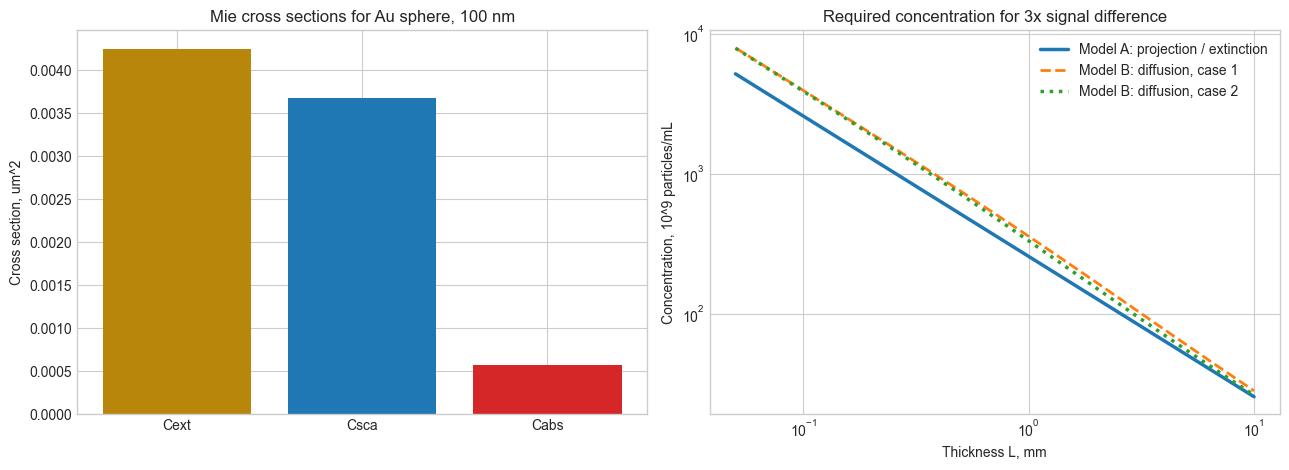

In [5]:
L_scan_mm = np.logspace(math.log10(0.05), math.log10(10.0), 120)
L_scan_cm = L_scan_mm / 10
N_projection_scan = np.array([concentration_projection(c_ext_cm2, L) for L in L_scan_cm])

N_diff_case1_scan = np.array([
    solve_concentration_diffusion(
        brain_cases['Case 1: mu_a=0.02, mu_s_prime=1.12 mm^-1']['mu_a'],
        brain_cases['Case 1: mu_a=0.02, mu_s_prime=1.12 mm^-1']['mu_sp'],
        L_mm,
        c_abs_cm2,
        c_sca_cm2,
        mie['g'],
    )
    for L_mm in L_scan_mm
])

N_diff_case2_scan = np.array([
    solve_concentration_diffusion(
        brain_cases['Case 2: mu_a=0.036, mu_s=22, g=0.9 -> mu_s_prime=2.2 mm^-1']['mu_a'],
        brain_cases['Case 2: mu_a=0.036, mu_s=22, g=0.9 -> mu_s_prime=2.2 mm^-1']['mu_sp'],
        L_mm,
        c_abs_cm2,
        c_sca_cm2,
        mie['g'],
    )
    for L_mm in L_scan_mm
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].bar(
    ['Cext', 'Csca', 'Cabs'],
    [c_ext_um2, c_sca_um2, c_abs_um2],
    color=['#b8860b', '#1f77b4', '#d62728'],
)
axes[0].set_ylabel('Cross section, um^2')
axes[0].set_title('Mie cross sections for Au sphere, 100 nm')

axes[1].plot(L_scan_mm, N_projection_scan / 1e9, lw=2.5, label='Model A: projection / extinction')
axes[1].plot(L_scan_mm, N_diff_case1_scan / 1e9, '--', lw=2, label='Model B: diffusion, case 1')
axes[1].plot(L_scan_mm, N_diff_case2_scan / 1e9, ':', lw=2.5, label='Model B: diffusion, case 2')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Thickness L, mm')
axes[1].set_ylabel('Concentration, 10^9 particles/mL')
axes[1].set_title('Required concentration for 3x signal difference')
axes[1].legend()

plt.tight_layout()

## Готовый ответ для сдачи

### 1. Основной ответ, если ОДТ понимать как проекционное ослабление

Для Au-сферы диаметром `100 нм` при `λ = 800 нм` в среде `n = 1.33` по теории Ми получено:

- `Qext ≈ 0.541`
- `Cext ≈ 4.252 × 10^-11 см²`
- `Csca ≈ 3.679 × 10^-11 см²`
- `Cabs ≈ 5.729 × 10^-12 см²`

Тогда концентрация, необходимая для 3-кратного изменения сигнала на проекции, равна

`N_A(L) = ln(3) / (4.252e-11 * L_cm)`

Численно:

- `L = 100 мкм`: `N_A ≈ 2.58 × 10^12 частиц/мл`
- `L = 1 мм`: `N_A ≈ 2.58 × 10^11 частиц/мл`
- `L = 10 мм`: `N_A ≈ 2.58 × 10^10 частиц/мл`

Соответствующая разность сигналов:

`Delta_S_dB = 10 * log10(3) ~= 4.77 dB`

Если фон принять за `0 дБ`, то сигнал после ослабления будет `-4.77 дБ` в шкале передачи или `+4.77 дБ` в шкале потерь.

### 2. Альтернативный ответ, если ОДТ понимать как диффузионную томографию

При диффузионной модели для типичных оптических свойств мозга мыши на `800 нм` получается тот же порядок концентраций:

- `L = 100 мкм`: `N_B ≈ (3.88–3.93) × 10^12 частиц/мл`
- `L = 1 мм`: `N_B ≈ (3.33–3.59) × 10^11 частиц/мл`
- `L = 10 мм`: `N_B ≈ (2.65–2.85) × 10^10 частиц/мл`

### 3. Практический вывод

Если преподаватель не уточняет толщину и не оговаривает диффузионную модель, наиболее естественный итоговый ответ для этой задачи такой:

- **формула**: `N(L) = ln(3) / (Cext * L)`;
- **при `L = 1 мм`**: `N ≈ 2.6 × 10^11 частиц/мл`;
- **разность сигналов**: `4.77 дБ`.

Это и есть наиболее вероятный «основной» ответ. Диффузионная трактовка даёт близкий порядок и может быть приложена как расширение решения.